In [ ]:
import deepxde as dde
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
D = 0.001
k_true = 0.01
k = dde.Variable(0.5)

In [ ]:
results = []

(101, 101)


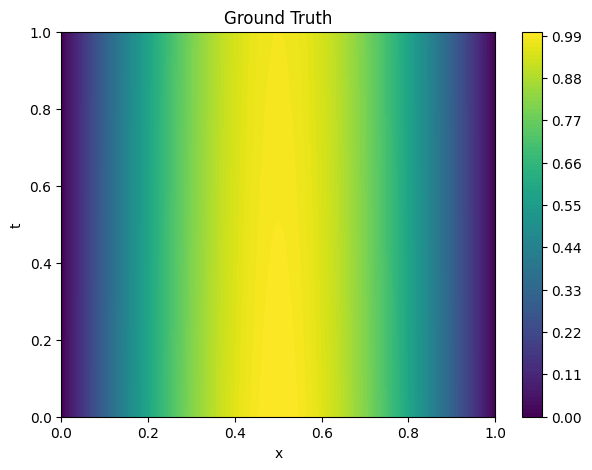

In [ ]:
Nx = 101
Nt = 101

x = np.linspace(0, 1, Nx)
t = np.linspace(0, 1, Nt)

dx = x[1] - x[0]

u0 = np.sin(np.pi * x)

def pde_rhs(t, u):

    dudt = np.zeros_like(u)

    dudt[1:-1] = (
        D * (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        - k_true * u[1:-1]
    )

    dudt[0] = 0
    dudt[-1] = 0

    return dudt

sol = solve_ivp(pde_rhs,[0,1],u0,t_eval=t)
U_exact = sol.y.T
print(U_exact.shape)

X, T = np.meshgrid(x, t)

plt.figure(figsize=(7,5))

plt.contourf(X, T, U_exact, 100)

plt.colorbar()

plt.xlabel("x")
plt.ylabel("t")
plt.title("Ground Truth")

plt.show()

X_flat = X.flatten()[:,None]
T_flat = T.flatten()[:,None]
U_flat = U_exact.flatten()[:,None]

N_obs = 100

idx = np.random.choice(len(X_flat),N_obs,replace=False)

x_obs = X_flat[idx]
t_obs = T_flat[idx]
u_obs = U_flat[idx]

noise = 0.05

u_obs = U_flat[idx] + noise * np.std(U_flat) * np.random.randn(*U_flat[idx].shape)

In [ ]:
def DiffusionReaction(x,y):

    u = y[:,0:1]

    u_t = dde.grad.jacobian(y,x,i=0,j=1)

    u_xx = dde.grad.hessian(y,x,component=0,i=0,j=0)

    residual = u_t - D*u_xx + k*u

    return residual

space = dde.geometry.Interval(0,1)

time = dde.geometry.TimeDomain(0,1)

geomtime = dde.geometry.GeometryXTime(space,time)

ob_xt = np.hstack((x_obs,t_obs))
observe_u = dde.icbc.PointSetBC(ob_xt,u_obs,component=0)


In [ ]:
data = dde.data.TimePDE(
    geomtime,
    DiffusionReaction,
    [observe_u],
    num_domain=1000,
    num_boundary=100,
    num_initial=100,
    anchors=ob_xt
)

layer_size = [2] + [50]*4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(
    layer_size,
    activation,
    initializer
)

model = dde.Model(data,net)

fname = "k.dat"

variable = dde.callbacks.VariableValue(

    [k],

    period=100,

    filename=fname
)

model.compile(
    "adam",
    lr=1e-3,
    external_trainable_variables=[k]
)

loss_history, train_state = model.train(
    iterations=10000,
    callbacks=[variable],
    display_every=1000
)

Compiling model...
'compile' took 0.005062 s

Training model...

Step      Train loss              Test loss               Test metric
0         [2.12e-03, 1.02e+00]    [2.12e-03, 1.02e+00]    []  
1000      [1.10e-04, 6.53e-04]    [1.10e-04, 6.53e-04]    []  
2000      [8.41e-04, 2.39e-03]    [8.41e-04, 2.39e-03]    []  
3000      [5.69e-06, 3.15e-04]    [5.69e-06, 3.15e-04]    []  
4000      [3.60e-06, 2.91e-04]    [3.60e-06, 2.91e-04]    []  
5000      [2.73e-06, 2.92e-04]    [2.73e-06, 2.92e-04]    []  
6000      [1.91e-06, 2.81e-04]    [1.91e-06, 2.81e-04]    []  
7000      [1.86e-06, 2.81e-04]    [1.86e-06, 2.81e-04]    []  
8000      [1.74e-06, 2.81e-04]    [1.74e-06, 2.81e-04]    []  
9000      [2.63e-05, 1.10e-03]    [2.63e-05, 1.10e-03]    []  
10000     [1.63e-06, 2.83e-04]    [1.63e-06, 2.83e-04]    []  

Best model at step 8000:
  train loss: 2.82e-04
  test loss: 2.82e-04
  test metric: []

'train' took 180.121317 s



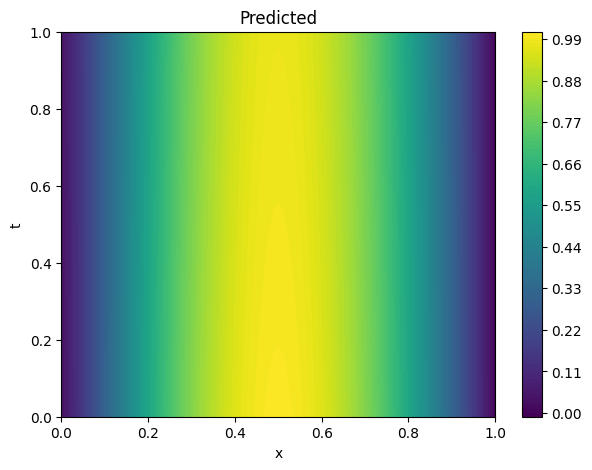

L2 Relative Error: 0.009280484052772193
k: 0.016304053


In [ ]:
X_test = X_flat
T_test = T_flat

XT = np.hstack((X_test, T_test))

u_pred = model.predict(XT)

u_pred = u_pred.reshape(U_exact.shape)

plt.figure(figsize=(7,5))

plt.contourf(X, T, u_pred, 100)

plt.colorbar()

plt.xlabel("x")
plt.ylabel("t")
plt.title("Predicted")

plt.show()
error = np.linalg.norm(u_pred - U_exact) / np.linalg.norm(U_exact)

print("L2 Relative Error:", error)
print("k:", k.numpy())

In [ ]:
train_loss = np.array(loss_history.loss_train)
test_loss = np.array(loss_history.loss_test)

print(train_loss.shape)
print(test_loss.shape)

(11, 2)
(11, 2)


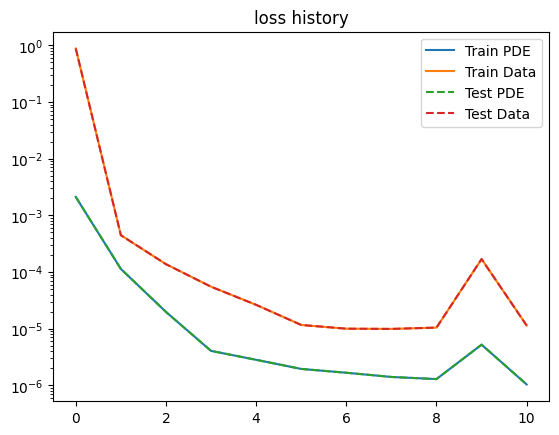

In [ ]:
plt.plot(train_loss[:,0], label="Train PDE")
plt.plot(train_loss[:,1], label="Train Data")

plt.plot(test_loss[:,0], "--", label="Test PDE")
plt.plot(test_loss[:,1], "--", label="Test Data")

plt.yscale("log")
plt.title("loss history")
plt.legend()
plt.show()

In [ ]:
k_hat = float(k)

results.append([
    noise * 100,
    k_hat,
    abs(k_hat - 0.01) / 0.01
])

   Noise (%)  Recovered k  Relative Error
0        0.0     0.009587        0.041326
1        1.0     0.011226        0.122599
2        5.0     0.016304        0.630405


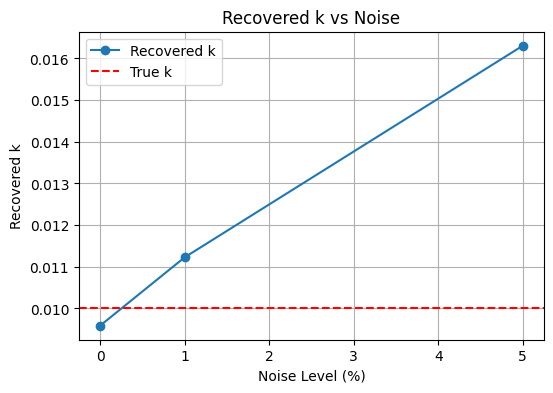

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    results,
    columns=["Noise (%)", "Recovered k", "Relative Error"]
)

print(df)

plt.figure(figsize=(6,4))
plt.plot(df["Noise (%)"], df["Recovered k"], "o-", label="Recovered k")
plt.axhline(0.01, color="red", linestyle="--", label="True k")
plt.xlabel("Noise Level (%)")
plt.ylabel("Recovered k")
plt.title("Recovered k vs Noise")
plt.grid(True)
plt.legend()
plt.show()